### library

In [1]:
library(Seurat)
library(monocle)
library(dplyr)
library(ggplot2)
library(reticulate)
library(tibble)
library(tidydr)

Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.3.3”

Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘monocle’ was built under R version 4.4.2”
Loading required package: Matrix

Warning message:
“package ‘Matrix’ was built under R version 4.3.3”
Loading required package: Biobase

Warning message:
“package ‘Biobase’ was built under R version 4.3.3”
Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.3”

Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects a

ERROR: Error in library(tidydr): there is no package called ‘tidydr’


In [ ]:
setwd('/home/wangj/ccRCC/')

### load data

In [ ]:
use_condaenv("ccRCC_env", required = TRUE)
sc <- import('scanpy')

In [ ]:
adata = sc$read_h5ad('data/epi_raw.h5ad')
adata

In [ ]:
donor = adata$obs$donor
donor = as.character(donor)
print(unique(donor))
phase = donor
phase[phase == 'QZX'] = 'G1-2'
phase[phase == 'ZSQ'] = 'G2-1'
phase[phase == 'LYM'] = 'G2'
phase[phase == 'CRS'] = 'G2-3'
phase[phase == 'LLF'] = 'G3-4'
adata$obs$phase = phase
adata$obs$phase = factor(adata$obs$phase, levels = c('G1-2', 'G2-1', 'G2', 'G2-3', 'G3-4'))

In [ ]:
sc$set_figure_params(dpi=300, facecolor='white',figsize=c(6,6),fontsize=10)
fig = sc$pl$umap(adata, color = c('phase'), frameon = FALSE,show=FALSE,save='_epi.png',legend_loc='on data')

In [ ]:
counts = adata$T$to_df()
counts = as.matrix(counts)
counts[1:5, 1:5]

In [ ]:
meta = adata$obs
meta = as.data.frame(meta)
meta[1:5, 1:5]

In [ ]:
sce <- CreateSeuratObject(counts = counts, min.cells = 0, min.features = 0)
sce

In [ ]:
sce$sample = meta$sample
table(sce$sample)

In [ ]:
sce$donor = meta$donor
table(sce$donor)

In [ ]:
adata

In [ ]:
sce$percent.mt = adata$obs$pct_counts_mt
range(sce$percent.mt)

### integration

In [ ]:
sceList <- SplitObject(sce, split.by = "donor")
sceList

In [ ]:
sceList_SCT <- lapply(X = sceList, FUN = function(x) SCTransform(x,vars.to.regress = 'nCount_RNA', verbose = FALSE))

In [ ]:
features <- SelectIntegrationFeatures(object.list = sceList_SCT, nfeatures = 3000)
sceList_SCT <- PrepSCTIntegration(object.list = sceList_SCT, anchor.features = features)

In [ ]:
anchors <- FindIntegrationAnchors(object.list = sceList_SCT, normalization.method = "SCT",anchor.features = features)
combined.sct <- IntegrateData(anchorset = anchors, normalization.method = "SCT")

In [ ]:
combined.sct <- RunPCA(combined.sct, verbose = FALSE)
combined.sct <- RunUMAP(combined.sct, reduction = "pca", dims = 1:30)

In [ ]:
options(repr.plot.width=10, repr.plot.height=4,repr.plot.res=250)
DimPlot(combined.sct, reduction = "umap", split.by = "donor",group.by = 'sample')

In [ ]:
combined.sct <- FindNeighbors(combined.sct, dims = 1:30)

In [ ]:
options(repr.plot.width=5, repr.plot.height=8,repr.plot.res=200)
# combined.sct <- FindClusters(object = combined.sct,resolution = c(seq(.1,1.2,.1)))
library(clustree)
clustree(combined.sct@meta.data, prefix = "integrated_snn_res.")
colnames(combined.sct@meta.data)

In [ ]:
options(repr.plot.width=5, repr.plot.height=4,repr.plot.res=250)
DimPlot(combined.sct, reduction = "umap",group.by = 'integrated_snn_res.0.4',label = TRUE, label.size = 3) + 
  NoLegend()

### load integrated data

In [ ]:
# saveRDS(combined.sct, file = 'data/combined.sct.rds')
combined.sct <- readRDS(file = 'data/combined.sct.rds')

In [ ]:
Idents(combined.sct) <- combined.sct$integrated_snn_res.0.4

In [ ]:
Colclus = paletteer::paletteer_d("ggsci::category20_d3")[10:20]
# names(Colclus) = unique(combined.sct$integrated_snn_res.0.4)
Colclus

<colors>
#17BECFFF #AEC7E8FF #FFBB78FF #98DF8AFF #FF9896FF #C5B0D5FF #C49C94FF #F7B6D2FF #C7C7C7FF #DBDB8DFF #9EDAE5FF 

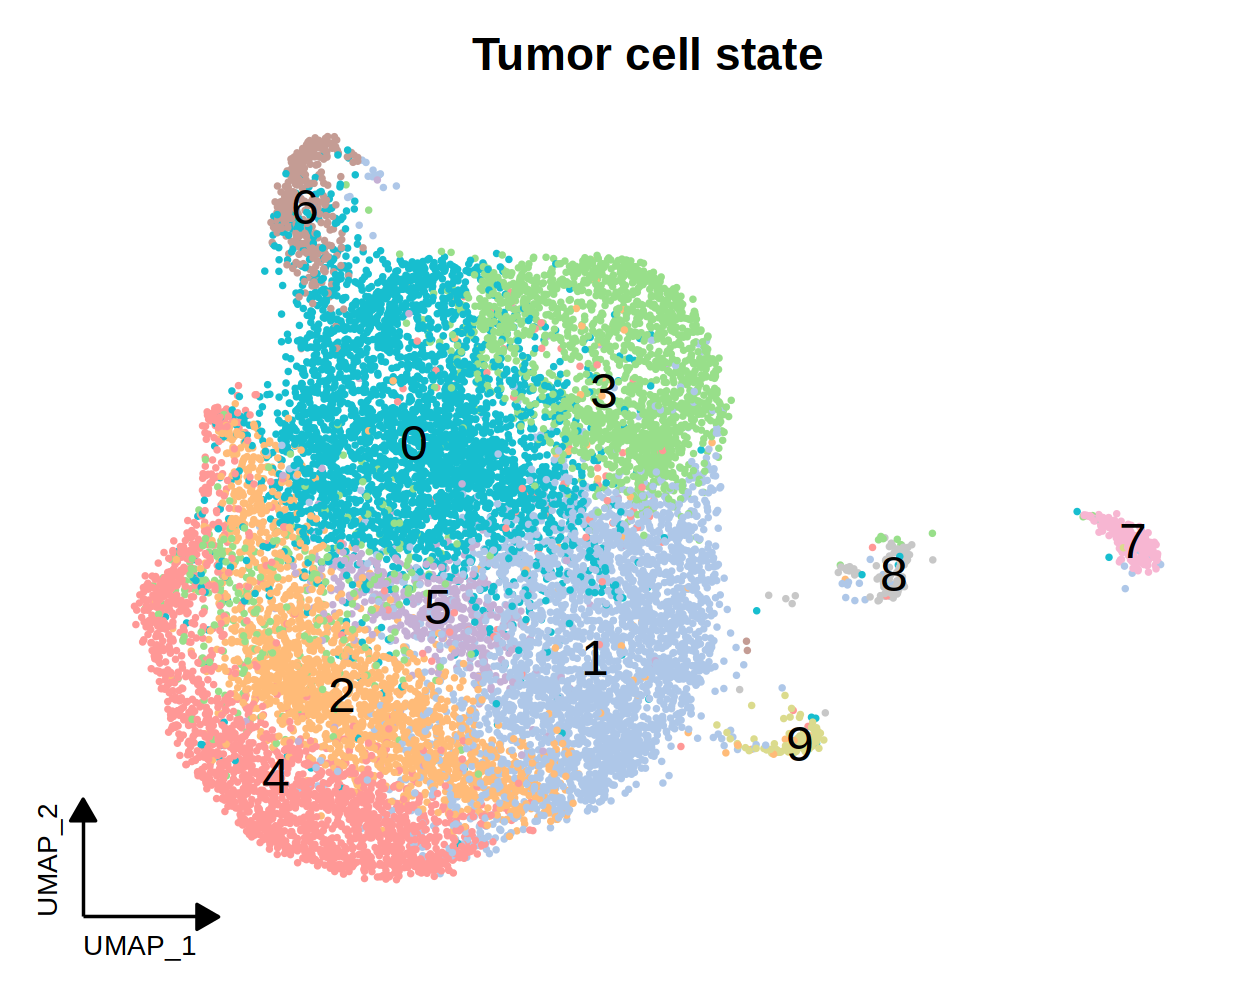

In [ ]:
options(repr.plot.width=5, repr.plot.height=4,repr.plot.res=250)
l=0.03
# png('figures/epi_umap.png', width = 1200, height = 1000, res = 300)
# pdf('figures/epi_umap.pdf', width = 5, height = 4)
DimPlot(combined.sct, reduction = "umap",group.by = 'integrated_snn_res.0.4',label = TRUE, label.size = 5,
cols = Colclus) + 
  ggtitle("Tumor cell state")+
  theme_dr(xlength = l*4, ylength = l*4.8,arrow = arrow(length = unit(0.1, "inches"),type = "closed"))+
  NoLegend()+
  theme(panel.grid = element_blank(),axis.title = element_text(face = 1,hjust = 0,size = 8),
        plot.title = element_text(hjust = 0.5,face = 'bold')) 
# dev.off()

In [ ]:
options(repr.plot.width=5, repr.plot.height=4,repr.plot.res=250)
l=0.03
combined.sct$sample = gsub('CRS-T','P9N',combined.sct$sample) %>% 
                      gsub('LLF-T','P6N',.) %>%
                      gsub('LYM-T','P11N',.) %>%
                      gsub('QZX-T','P8N',.) %>%
                      gsub('ZSQ-T','P7N',.)
png('figures/epi_umap_sample.png', width = 1600, height = 900, res = 300)
DimPlot(combined.sct, reduction = "umap",group.by = 'sample',label = F,pt.size = 0.1) + 
  ggtitle("Tumor cells")+
  theme_dr(xlength = l*4, ylength = l*4.8,arrow = arrow(length = unit(0.1, "inches"),type = "closed"))+
  theme(panel.grid = element_blank(),axis.title = element_text(face = 1,hjust = 0,size = 8),
        plot.title = element_text(hjust = 0.5,face = 'bold'),text=element_text(size=12)) +
    guides(colour = guide_legend(ncol = 2,override.aes = list(size=3),title = 'Sample'))
dev.off()

pdf 
  2

### proportion

In [ ]:
### distribution of sample in clusters
Freq <- table(combined.sct$integrated_snn_res.0.4, combined.sct$sample) %>% data.frame
colnames(Freq) <- c('Cluster', 'Sample', 'Freq')
Freq$Cluster <- paste0('Cluster', Freq$Cluster) 
png('figures/epi_cluster_sample.png', width = 1700, height = 950, res = 300)
ggplot(Freq, aes(x = Sample, y = Freq, fill = Cluster)) +
  geom_bar(stat = 'identity', position = 'fill',color='black') +
  labs(x = 'Sample', y = 'Proportion', fill = 'Cluster') +
  theme_classic() +
  scale_fill_manual(values = Colclus) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),legend.position = 'right')
dev.off()

pdf 
  2

### Run DEGs

In [ ]:
Idents(combined.sct) <- combined.sct$integrated_snn_res.0.4
# Idents(combined.sct) <- combined.sct$State

In [ ]:
DEGs_clu = FindAllMarkers(combined.sct, only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.5,return.thresh = 0.05,assay = 'RNA')
DEGs_clu = filter(DEGs_clu, p_val_adj < 0.05)

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9



In [ ]:
TopDEGs_clu = DEGs_clu %>% group_by(cluster) %>% top_n(100, wt = avg_log2FC)
combined.sct <- ScaleData(combined.sct, features = TopDEGs_clu$gene,assay = 'RNA')

Centering and scaling data matrix



In [ ]:
library(ComplexHeatmap)
library(circlize)
library(tibble)
mat = combined.sct@assays$RNA@scale.data[TopDEGs_clu$gene,]
mat = t(mat)
matmean = aggregate(mat,by = list(Cluster = combined.sct$integrated_snn_res.0.4),mean)
# matmean = aggregate(mat, by = list(Cluster = combined.sct$State), mean)
matmean  <- matmean %>% column_to_rownames('Cluster') %>% t()
matmean = matmean[,levels(combined.sct)]
head(matmean)

,0,1,2,3,4,5,6,7,8,9
DUSP1,0.4616974,-0.3253965,-0.4026256,0.029819540,-0.1705110,0.11350034,0.6288597,0.4257283,0.12641266,-0.06035182
IGFBP5,0.3473772,-0.1956590,-0.1505630,-0.221437483,-0.3214064,0.14210976,1.3460428,0.5214152,-0.07201096,-0.07306748
FOS,0.5272281,-0.2712715,-0.4414900,0.008632519,-0.1109109,-0.11610235,0.3500205,-0.0273266,-0.12047258,-0.23648853
JUNB,0.4256953,-0.3300331,-0.4482813,0.140516192,-0.1338752,-0.18930890,0.7825341,0.7671037,0.04827710,-0.32904799
CEBPD,0.3774112,-0.2682769,-0.3074793,0.074081901,-0.1781466,-0.02468953,0.5168089,0.4117029,0.07411510,-0.12153494
S100A6,0.2174386,-0.2427135,-0.1785435,0.061552181,-0.1476058,0.17263929,0.4462450,0.7427275,0.09967703,-0.03259562


In [ ]:
meta_genes_list

In [ ]:
keyGene <- unique(unlist(meta_genes_list))
keyGene <- c(keyGene,c('PTPRC','CCL4','FYN','SRGN','LYZ','MGP'))
topdegs = DEGs_clu %>% group_by(cluster) %>% top_n(10, wt = avg_log2FC)
keyGene <- keyGene[keyGene %in% topdegs$gene]
keyGene_pos <- which(rownames(matmean) %in% keyGene)
keyGene <- rownames(matmean)[keyGene_pos]
row_anno <- rowAnnotation(keypath = anno_mark(at = keyGene_pos,labels = keyGene,labels_gp = gpar(fontsize = 8)))

In [ ]:
col <- circlize::colorRamp2(c(-1,0,1), c("#51C3CC","white","#DF0000"), transparency = 0.3, space = "LAB")
h = Heatmap(matmean,
            use_raster = F,
            right_annotation = row_anno,
            show_column_names = T,
            show_row_names = F,
            col = col,
            cluster_rows = F,
            cluster_columns = F,
            heatmap_legend_param = list(title = "mean expression",
                                        title_position = 'lefttop',
                                        legend_direction = "horizontal",
                                        at = c(-1,0,1),
                                        labels = c( "-1", "0","1"),
                                        labels_gp = gpar(fontsize = 15),
                                        title_gp = gpar(fontsize = 15, fontface = "bold"),
                                        legend_width = unit(20, "mm")))

In [ ]:
options(repr.plot.width=3, repr.plot.height=6,repr.plot.res=250)
# png('figures/epi_heatmap.png', width = 800, height = 1500, res = 300)
pdf('figures/epi_heatmap.pdf', width = 2.8, height = 6)
draw(h,heatmap_legend_side = "top",merge_legend = F,align_heatmap_legend = "heatmap_left")
dev.off()

In [ ]:
TopDEGs_clu = DEGs_clu %>% group_by(cluster) %>% top_n(5, wt = avg_log2FC)
cluster_markers = split(TopDEGs_clu$gene, TopDEGs_clu$cluster)
names(cluster_markers) <- paste0('Cluster', names(cluster_markers))
### remove duplicate markers in all clusters
unique_markers <- lapply(names(cluster_markers), function(ct) {
  others <- unlist(cluster_markers[names(cluster_markers) != ct])
  setdiff(cluster_markers[[ct]], others)
})
names(unique_markers) <- names(cluster_markers)
unique_markers

$Cluster0
[1] "IGFBP5" "MT1X"   "HSPA1A" "HSPA1B" "IGKC"  

$Cluster1
[1] "NLGN1"      "PKHD1"      "PTH2R"      "AL391117.1" "ROBO2"     

$Cluster2
[1] "MT-ND2"  "MT-ND1"  "MT-ND3"  "MT-ND4"  "MT-ND4L"

$Cluster3
[1] "CXCL10"   "BIRC3"    "GBP1"     "CCL2"     "HLA-DQA1"

$Cluster4
[1] "NAT8"    "GSTA1"   "CUBN"    "SLC5A12" "GSTA2"  

$Cluster5
[1] "PDE4C"     "AMPD3"     "LRRC23"    "LINC01619" "NFE2L3"   

$Cluster6
[1] "SFRP2"  "COL1A1" "COL3A1" "H19"    "CPE"   

$Cluster7
[1] "PTPRC"  "S100A4" "FYN"    "CCL4"  

$Cluster8
[1] "LYZ"  "C1QA" "MGP"  "RGS5"

$Cluster9
[1] "MIR924HG" "STMN1"    "H2AFZ"    "TUBA1B"   "LGALS1"

In [ ]:
options(repr.plot.width=12, repr.plot.height=5,repr.plot.res=250)
png('figures/epi_dotplot.png', width = 2400, height = 1000, res = 200)
DotPlot(combined.sct, features = unique_markers, assay = 'SCT')+ 
  scale_color_gradient2(low = "#51C3CC", mid = "white", high = "#DF0000", midpoint = 0) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 1))
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

pdf 
  2

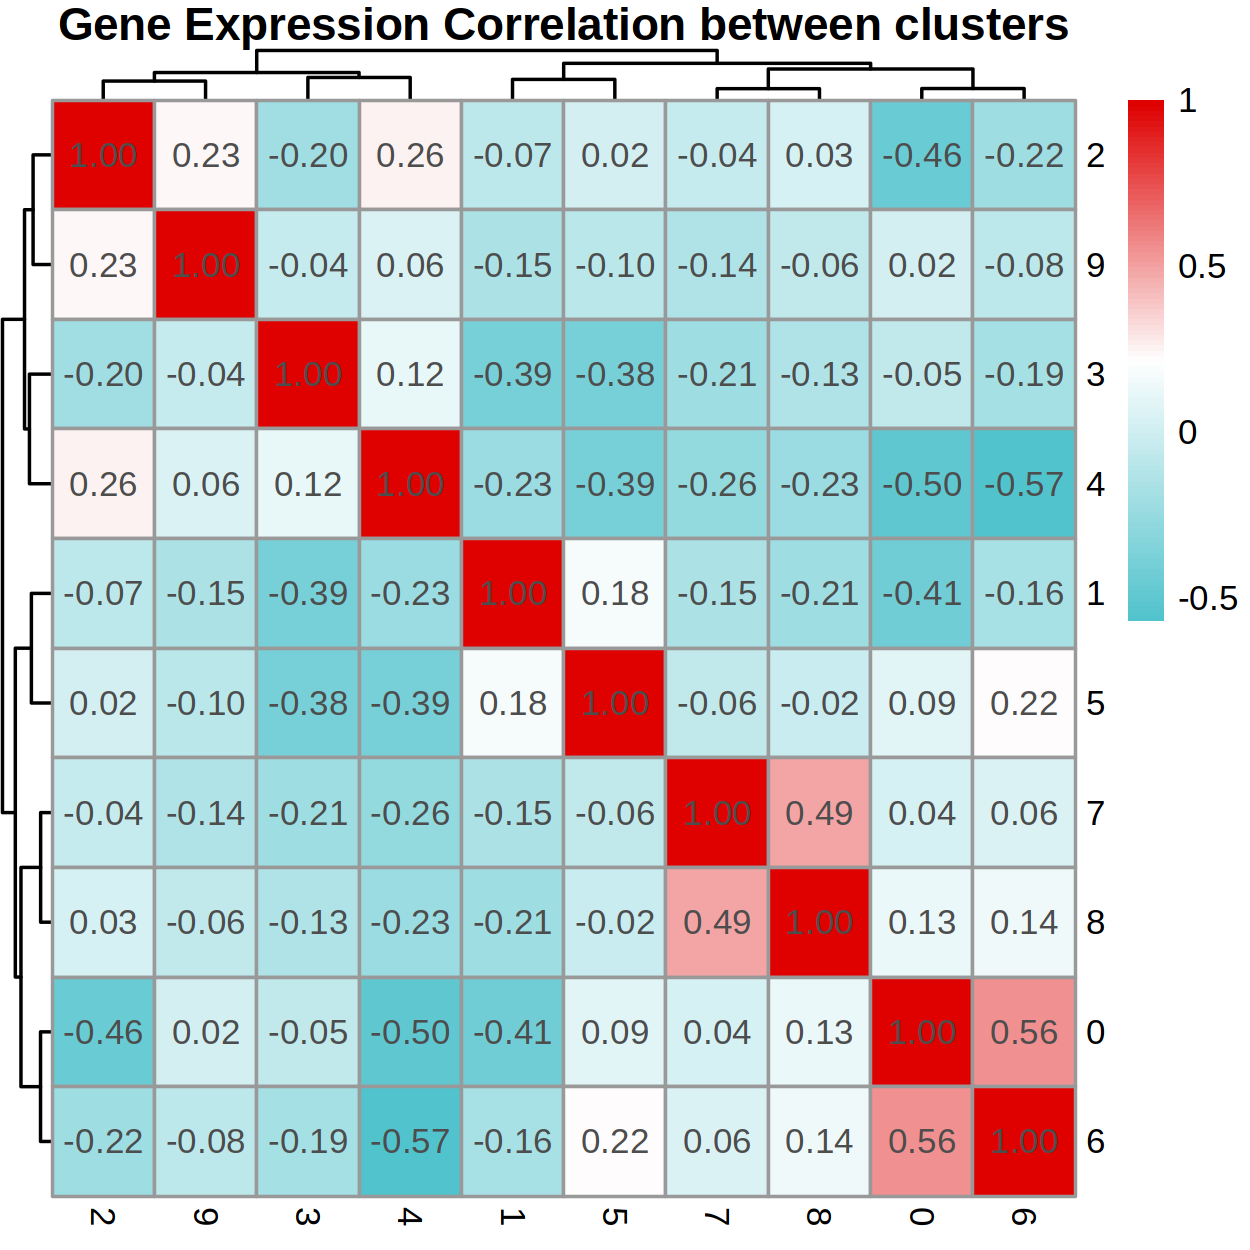

In [ ]:
### correlation bwteen clusters
cor_mat <- cor(matmean, method = "pearson")
options(repr.plot.width=5, repr.plot.height=5,repr.plot.res=250)
p<-pheatmap::pheatmap(cor_mat, 
         clustering_distance_rows = "euclidean", 
         clustering_distance_cols = "euclidean", 
         clustering_method = "ward.D2",
         color = colorRampPalette(c("#51C3CC","white","#DF0000"))(100),
         display_numbers = TRUE, 
         fontsize_number = 10,
         treeheight_row = 10,treeheight_col = 10,
         main = "Gene Expression Correlation between clusters")
png('figures/epi_correlation_heatmap.png', width = 1400, height = 1300, res = 300)
p
dev.off()

### enrichment

In [ ]:
library(clusterProfiler)
pathways = read.gmt("/mnt/data/wangj/scripts/c5.all.v2025.1.Hs.symbols.gmt")
pathways = filter(pathways,grepl('GOBP',pathways$term))

In [ ]:
TopDEGs_clu = filter(DEGs_clu, avg_log2FC>0.5)
table(TopDEGs_clu$cluster)

In [ ]:
gdf = data.frame()
for (i in unique(TopDEGs_clu$cluster)) {
  print(i)
  genelist = filter(TopDEGs_clu,cluster==i)$gene
  genelist <- unique(genelist)
  ego <- enricher(gene = genelist, universe = rownames(combined.sct@assays$RNA),TERM2GENE = pathways)
  # go <- ego@result[,c('ID',"Description","qvalue","GeneRatio",'Count','geneID','p.adjust')]
  go <- ego@result
  go <- go %>% filter(qvalue < 0.05)
  go$State <- i
  gdf <- rbind(gdf,go)
}

In [ ]:
gdf_plot = gdf %>% group_by(State) %>% top_n(n = 5,wt = -qvalue)
gdf_plot$ID = gsub('GOBP_','',gdf_plot$Description)
gdf_plot$ID = stringr::str_to_title(gdf_plot$ID, locale = "en")
gdf_plot$ID = gsub('_',' ',gdf_plot$ID)
gdf_plot$ID = gsub('ii','II',gdf_plot$ID)
gdf_plot = filter(gdf_plot,State %in% c('Cell_cycle','MHCII','Cell_death','PT','EMT','Stress'))
gdf_plot[1:5,]

In [ ]:
cal_genesimilarity <- function(df, gene_col = "geneID", group_col = "ID", sep = "/") {
  gene_sets <- tapply(df[[gene_col]], df[[group_col]], function(x) unique(unlist(strsplit(x, sep))))
  groups <- names(gene_sets)
  n <- length(groups)
  sim_mat <- matrix(0, nrow = n, ncol = n, dimnames = list(groups, groups))
  for (i in seq_len(n)) {
    for (j in seq_len(n)) {
      inter <- length(intersect(gene_sets[[i]], gene_sets[[j]]))
      union <- length(union(gene_sets[[i]], gene_sets[[j]]))
      sim_mat[i, j] <- ifelse(union == 0, 0, inter / union) 
    }
  }
  return(sim_mat)
}

In [ ]:
merge_genesets <- function(df,group,k = 3) {
  gdf_plot_list =  split(df, df[,group])
  gdf_plot_list_merged <- list()
  sim_mat_list <- lapply(gdf_plot_list, cal_genesimilarity, gene_col = "geneID", group_col = "ID", sep = "/")
  for(i in seq_along(sim_mat_list)) {
    sim_mat <- sim_mat_list[[i]]
    dist_mat <- as.dist(1 - sim_mat)
    hc <- hclust(dist_mat, method = "ward.D2")
    groups <- cutree(hc, k = k)
    
    group_names <- split(names(groups), groups)
    gene_sets <- tapply(gdf_plot_list[[i]]$geneID, gdf_plot_list[[i]]$ID, function(x) unique(unlist(strsplit(x, "/"))))
    
    res <- sapply(group_names, function(ids) {
      if(length(ids) == 1) {
        return(ids)
      } else {
        gene_counts <- sapply(ids, function(id) length(gene_sets[[id]]))
        return(ids[which.max(gene_counts)])
      }
    })
    gdf_plot_list_merged[[i]] <- gdf_plot_list[[i]][gdf_plot_list[[i]]$ID %in% res, ]
  }
  merged_df <- do.call(rbind, gdf_plot_list_merged)
  return(merged_df)
}


In [ ]:
gdf_plot_merge = merge_genesets(gdf_plot,'State')

In [ ]:
Colstate = c('#FF9896FF','#17BECFFF','#AEC7E8FF','#98DF8AFF','#C49C94FF','#F7B6D2FF','#DBDB8DFF')
names(Colstate) = c('PT','Stress','Cell_death','MHCII','EMT','Immnue','Cell_cycle')

In [ ]:
options(repr.plot.width=7, repr.plot.height=6,repr.plot.res=200)
# png('figures/epi_enrich.png', width = 900, height = 1500, res = 200)
pdf('figures/epi_enrich.pdf', width = 4.5, height = 7)
gdf_plot_merge$State = factor(gdf_plot_merge$State, levels = c('PT','Stress','Cell_death','MHCII','EMT','Immnue','Cell_cycle'))
th=45
gdf_plot_merge$wrapped_label <- stringr::str_wrap(gdf_plot_merge$ID, width = th)
ggplot(gdf_plot_merge, aes(x = -log10(qvalue), y = reorder(ID, -qvalue), fill = State)) +
  theme_bw() +
  # 使用换行后的标签
  geom_text(aes(label = wrapped_label, x = 0.1, size = -log10(qvalue), color = State), 
            hjust = 0, lineheight = 0.8) +
  facet_wrap(~State, ncol = 1, scales = "free_y") +
  theme(
    axis.text = element_blank(), 
    axis.ticks = element_blank(),
    panel.grid = element_blank(),
    axis.title = element_blank(),
    axis.line.y = element_blank(),
    strip.background = element_blank(),
    strip.text = element_blank(),
    legend.position = 'none',
    panel.spacing.y = unit(0.5, "lines")
  ) +
  scale_x_continuous(expand = expansion(add = c(0, 0.1))) +
  scale_color_manual(values = Colstate) +
  scale_size_continuous(range = c(4.8, 6)) +
  coord_cartesian(clip = "off") +
  ggh4x::force_panelsizes(rows = unit(c(7,4,6,7,4,4), "lines"))
dev.off()

### assign State

In [ ]:
meta_genes = read.csv('data/meta_program_genes_Li22_CancerCell.csv', header = TRUE)
meta_genes_list = lapply(colnames(meta_genes), function(x) {
    genes = meta_genes[[x]][!is.na(meta_genes[[x]])]
    genes = genes[genes != '']
    genes = genes[genes %in% rownames(combined.sct)]
    return(genes)
})
names(meta_genes_list) <- colnames(meta_genes)
meta_genes_list

$cell_cycle
 [1] "TK1"   "RRM2"  "PTTG1" "CENPF" "TOP2A" "BIRC5" "TPX2"  "CCNB1" "UBE2C"
[10] "H2AFZ" "ASPM"  "TYMS"  "ANLN" 

$MHC.II
 [1] "HLA-DRA"  "HLA-DQA1" "IGFBP3"   "VCAM1"    "UBD"      "SOD2"    
 [7] "LAP3"     "CLU"      "HLA-DRB1" "HLA-DPA1" "CD74"     "DEFB1"   

$Cell_death
[1] "SULT1C2" "DOC2A"   "MBNL1"   "NEAT1"   "DNAH11" 

$PT
 [1] "ACSM2B"  "NAT8"    "GSTA1"   "ACSM2A"  "LGALS2"  "CUBN"    "PEPD"   
 [8] "KHK"     "PDZK1"   "BBOX1"   "SLC6A13" "GAL3ST1" "SLC5A12" "PRAP1"  
[15] "AQP1"    "CXCL14"  "SMIM24"  "GPX3"    "PCSK1N"  "LRP2"    "SLC17A3"
[22] "TSPAN1" 

$EMT
 [1] "CAV1"     "TGM2"     "FSTL3"    "SERPINE1" "KRT19"    "C3"      
 [7] "S100A6"   "EMP3"     "MT2A"     "TM4SF1"   "TGFBI"    "LGALS1"  
[13] "MARCKSL1" "BIRC3"    "LOX"      "ANXA2"    "MMP7"    

$Stress
 [1] "EGR1"     "FOS"      "IER2"     "ATF3"     "JUN"      "FOSB"    
 [7] "PPP1R15A" "GADD45B"  "CDKN1A"   "BTG2"     "DNAJB1"   "ZFP36"   
[13] "JUNB"     "HSPA1B"   "HSPA1A"   "CXCL2"    "NFKBIZ"   "RHOB"    
[19] "ADM"      "ELF3"

In [ ]:
combined.sct <- AddModuleScore(combined.sct, features = meta_genes_list,assay = 'SCT',name = names(meta_genes_list))

In [ ]:
index <- c(22:27)
print(colnames(combined.sct@meta.data)[index])
colnames(combined.sct@meta.data)[index] <- c('Cell_cycle','MHCII','Cell_death','PT','EMT','Stress')

[1] "cell_cycle1" "MHC.II2"     "Cell_death3" "PT4"         "EMT5"       
[6] "Stress6"    


In [ ]:
show_features <- c('Stress','Cell_death','MHCII','PT','EMT','Cell_cycle')

In [ ]:
options(repr.plot.width=6, repr.plot.height=2,repr.plot.res=250)
# png('figures/epi_dotplot.png', width = 900, height = 600, res = 300)
pdf('figures/epi_dotplot.pdf', width = 5.5, height = 2.5)
DotPlot(combined.sct, features = show_features, assay = 'SCT') + RotatedAxis() + coord_flip() +
  scale_color_gradient2(low = "#51C3CC", mid = "white", high = "#DF0000", midpoint = 0) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),axis.title.x = element_blank(),plot.margin = margin(25,1,5,1))+
  xlab('Signature') 
dev.off()

In [ ]:
show_features = c('PTPRC','LYZ')

In [ ]:
options(repr.plot.width=8, repr.plot.height=4,repr.plot.res=250)
l=0.05
# png('figures/epi_umap_feature.png', width = 600, height = 1000, res = 300)
pdf('figures/epi_umap_feature.pdf', width = 4.2, height = 2)
FeaturePlot(combined.sct, features = show_features, reduction = "umap", ncol = 2, label = TRUE, label.size = 3,order = T,pt.size = 0.1) &
scale_color_gradient2(low = "#51C3CC", mid = "white", high = "#DF0000", midpoint = 3) &
theme_dr(xlength = l*4, ylength = l*4.8,arrow = arrow(length = unit(0.1, "inches"),type = "closed")) & NoLegend() &
theme(panel.grid = element_blank(),axis.title = element_text(face = 1,hjust = 0,size = 8),
        plot.title = element_text(hjust = 0.5,face = 'bold')) 
dev.off()

In [ ]:
# VlnPlot(combined.sct, features = c('nCount_RNA','percent.mt'), ncol = 2, pt.size = 0, assay = 'SCT')
df_plot = aggregate(combined.sct@meta.data[,c('nCount_RNA','percent.mt')], by = list(combined.sct$integrated_snn_res.0.4), FUN = mean)
df_plot = as.data.frame(df_plot)
colnames(df_plot)[1] <- 'Cluster'
# png('figures/epi_umap_nCount_percent_mt.png', width = 700, height = 700, res = 300)
pdf('figures/epi_umap_nCount_percent_mt.pdf', width = 2.5, height = 2.6)
df_plot %>% 
    ggplot(aes(x = percent.mt, y = nCount_RNA,size=percent.mt,color=percent.mt)) +
    geom_point(alpha=0.8) +
    ggrepel::geom_text_repel(aes(label=Cluster), size=5, hjust=0.5, vjust=-1,color='black') +
    theme_classic()+
    theme(legend.position = "none")+
    scale_color_gradient2(high = "#3A3A3A", mid = "white", low = "#A41125", midpoint = 10)+
    scale_x_continuous(expand = c(0.1, 0.1)) +
    scale_y_continuous(expand = c(0.1, 0.1)) 
dev.off()

In [ ]:
State = as.character(combined.sct$integrated_snn_res.0.4)
State[State == '0'] = 'Stress'
State[State == '1'] = 'Cell_death'
State[State == '2'] = 'LowQ'
State[State == '3'] = 'MHCII'
State[State == '4'] = 'PT'
State[State == '5'] = 'Cell_death'
State[State == '6'] = 'EMT'
State[State == '7'] = 'Immune'
State[State == '8'] = 'Immune'
State[State == '9'] = 'Cell_cycle'

combined.sct$State <- State
table(combined.sct$State)


Cell_cycle Cell_death        EMT     Immune       LowQ      MHCII         PT 
        99       3513        377        350       2069       2039       2000 
    Stress 
      3604 

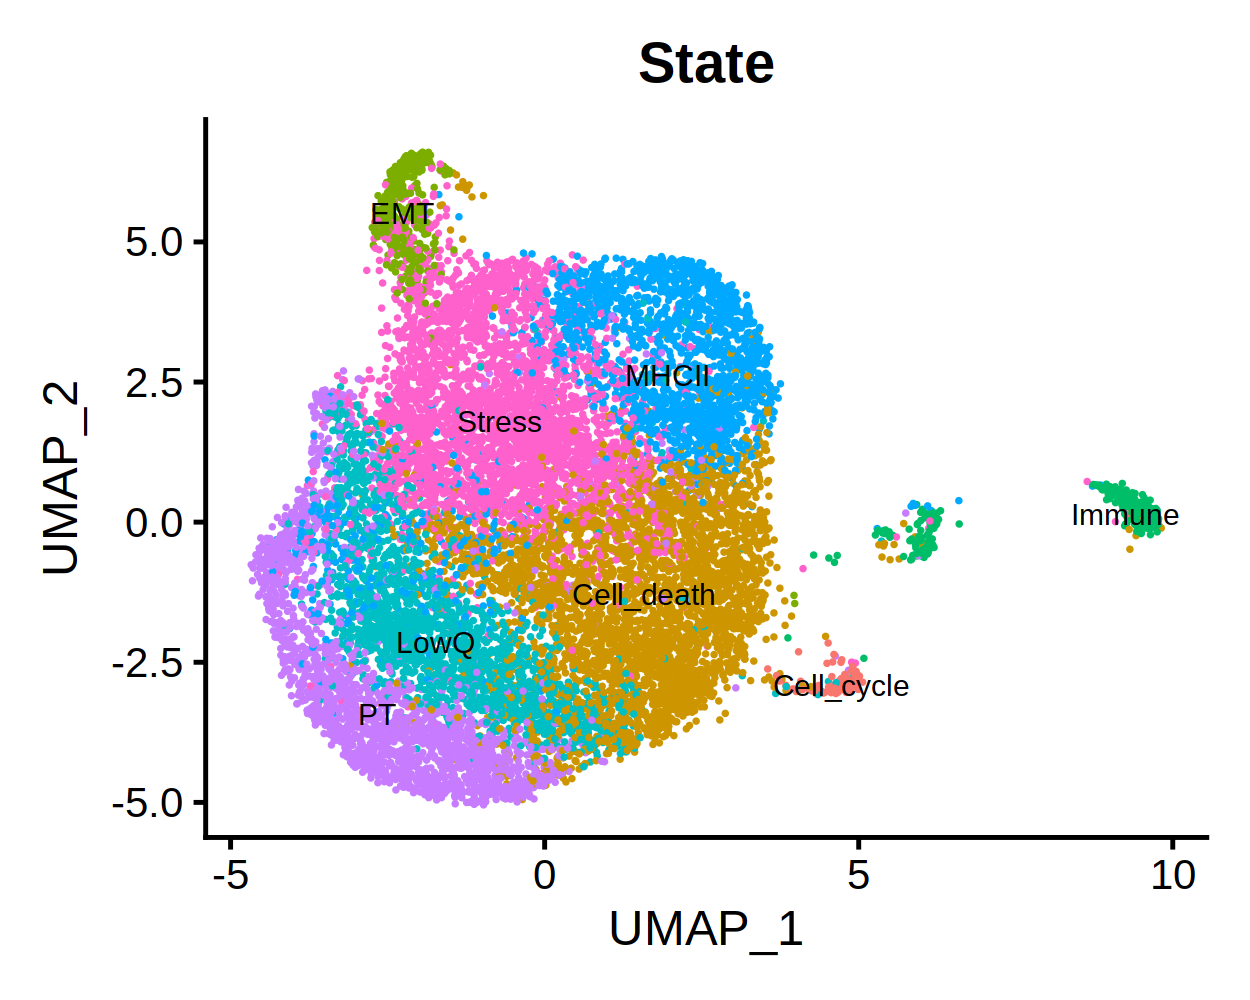

In [ ]:
options(repr.plot.width=5, repr.plot.height=4,repr.plot.res=250)
DimPlot(combined.sct, reduction = "umap", group.by = 'State', label = TRUE, label.size = 3) + NoLegend()

In [ ]:
show_features <- c('Stress','Cell_death','MHCII','PT','EMT','Cell_cycle')
Idents(combined.sct) <- combined.sct$State
png('figures/epi_umap_feature_state.png', width = 2000, height = 1300, res = 300)
FeaturePlot(combined.sct, features = show_features, reduction = "umap", ncol = 3, label = TRUE, label.size = 3,order = T,pt.size = 0.1,repel = T) &
scale_color_gradient2(low = "#51C3CC", mid = "white", high = "#DF0000", midpoint = 0) &
theme_dr(xlength = l*4, ylength = l*4.8,arrow = arrow(length = unit(0.1, "inches"),type = "closed")) & NoLegend() &
theme(panel.grid = element_blank(),axis.title = element_text(face = 1,hjust = 0,size = 8),
        plot.title = element_text(hjust = 0.5,face = 'bold')) 
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

### subset tumor

In [ ]:
Epi = combined.sct[, !combined.sct$State %in% c('LowQ', 'Immune')]
Epi

In [ ]:
library(pheatmap)
### distribution of state in sample
Freq <- table(Epi$sample,Epi$State) %>% as.data.frame.array
Freq <- t(Freq)/colSums(Freq)

cor_mat <- cor(Freq, method = "pearson")
# options(repr.plot.width=5, repr.plot.height=5,repr.plot.res=250)
p<-pheatmap(cor_mat, 
         clustering_distance_rows = "euclidean", 
         clustering_distance_cols = "euclidean", 
         clustering_method = "ward.D2",
         color = colorRampPalette(c("#51C3CC","white","#DF0000"))(100),
         fontsize_number = 10,treeheight_row = 10,treeheight_col = 10)
# png('figures/epi_state_sample_correlation.png', width = 1200, height = 1100, res = 300)
pdf('figures/epi_state_sample_correlation.pdf', width = 4.5, height = 4)
print(p)
dev.off()

In [ ]:
C1 <- c("LYM-T2", "CRS-T2", "LYM-T1", "ZSQ-T2")
C2 <- c("LLF-T2", "QZX-T3")
C3 <- c("LLF-T3", "ZSQ-T1")
C4 <- c("CRS-T1", "LLF-T1", "ZSQ-T3", "QZX-T1", "CRS-T3", "QZX-T2")

In [ ]:
options(repr.plot.width=3, repr.plot.height=4,repr.plot.res=250)
library(reshape2)
# png('figures/epi_state_boxplot.png', width = 1000, height = 500, res = 300)
pdf('figures/epi_state_boxplot.pdf', width = 4.5, height = 2.4)
Freq %>% 
melt(.,value.name = 'Proportion', varnames = c('State','Sample')) %>%
mutate(EMT_type = ifelse(Sample %in% C1, 'C1',
                                 ifelse(Sample %in% C2, 'C2',
                                        ifelse(Sample %in% C3, 'C3', 'C4')))) %>%
    ggplot(aes(x = State, y = Proportion,fill=State)) +
    geom_boxplot(outlier.shape = NA)+
    geom_jitter(aes(color = Sample), width = 0.2, size = 1,color='Grey70') +
    labs(y = 'Proportion') +
    theme_bw() +
    scale_fill_manual(values = Colstate) +
    theme(axis.text.x = element_blank(),
          axis.ticks.x = element_blank(),
          axis.title.x = element_blank(),
          legend.position = 'none',
          strip.background = element_rect(fill = "white", color = "black"),
          panel.grid.major = element_blank(),
          panel.grid.minor = element_blank())+
    facet_grid(~EMT_type) +
    scale_y_continuous(expand = expansion(mult = c(0, 0.05)))
dev.off()

In [ ]:
Epi <- RunPCA(Epi, verbose = FALSE)
Epi <- RunUMAP(Epi, reduction = "pca", dims = 1:20)

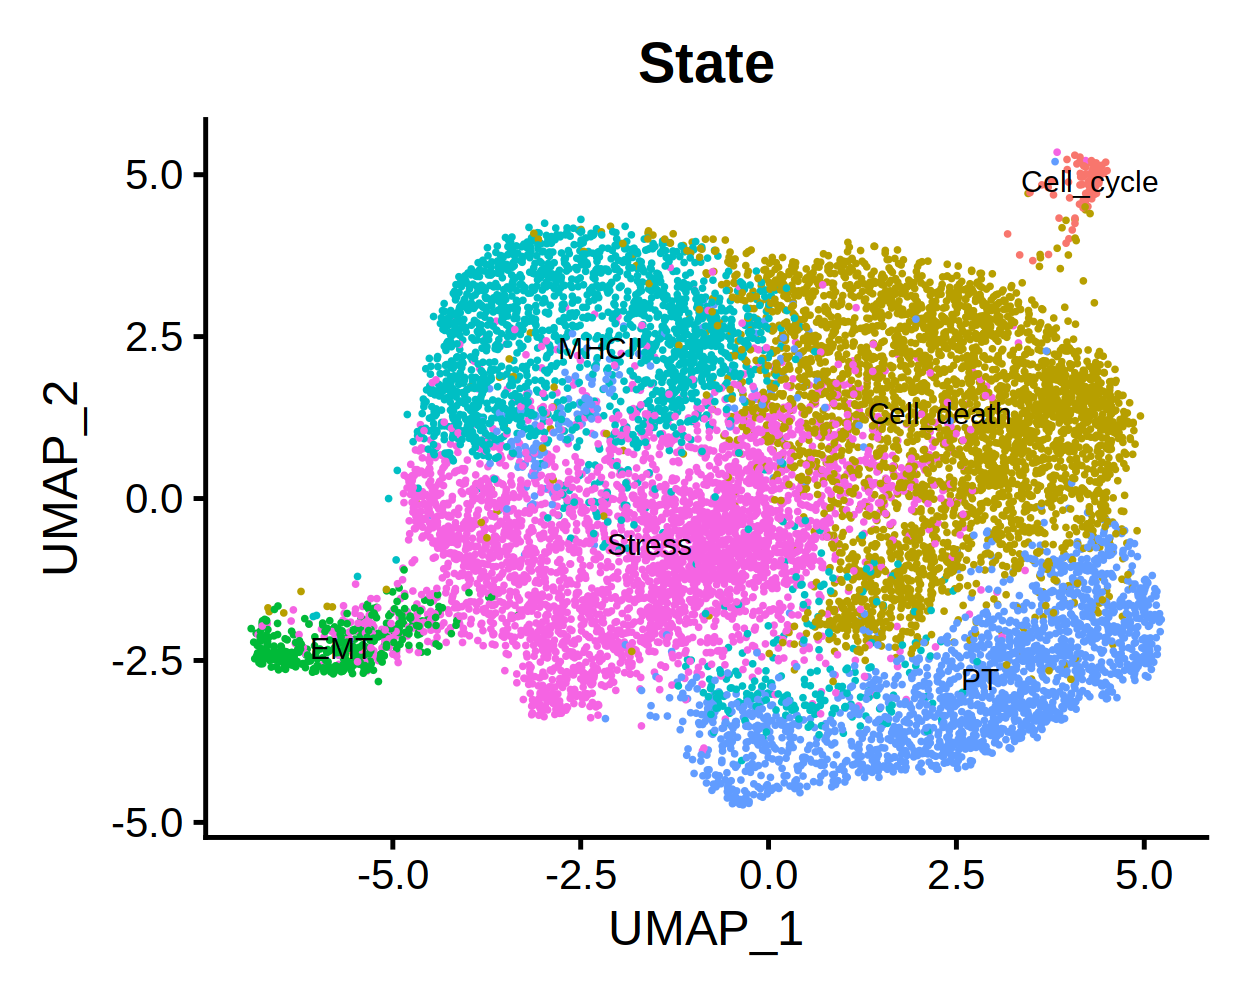

In [ ]:
options(repr.plot.width=5, repr.plot.height=4,repr.plot.res=250)
DimPlot(Epi, reduction = "umap", group.by = 'State', label = TRUE, label.size = 3) + NoLegend()

In [ ]:
l=0.03
group = as.character(Epi$integrated_snn_res.0.4)
group[group == '0'] = '0:Stress'
group[group == '1'] = '1:Cell_death'
group[group == '3'] = '3:MHCII' 
group[group == '4'] = '4:PT'
group[group == '5'] = '5:Cell_death'
group[group == '6'] = '6:EMT'
group[group == '9'] = '7:Cell_cycle'
Epi$group <- group

png('figures/epi_umap_filtered.png', width = 1100, height = 1000, res = 300)
DimPlot(Epi, reduction = "umap",group.by = 'group',label = TRUE, label.size = 5,repel = T,
cols = Colclus[c(1,2,4:7,10)]) + 
  ggtitle("Tumor cell state")+
  theme_dr(xlength = l*4, ylength = l*4.8,arrow = arrow(length = unit(0.1, "inches"),type = "closed"))+
  NoLegend()+
  theme(panel.grid = element_blank(),axis.title = element_text(face = 1,hjust = 0,size = 8),
        plot.title = element_text(hjust = 0.5,face = 'bold')) 
dev.off()

png 
  2

In [ ]:
# saveRDS(Epi, file = 'data/Epi.rds')
Epi <- readRDS(file = 'data/Epi.rds')

### TF

In [ ]:
Epi_all <- readRDS(file = 'data/Epi.rds')

In [ ]:
library(SCENIC)
library(SCopeLoomR)

In [ ]:
# counts <- as.matrix(Epi@assays$RNA@counts)
# print(dim(counts))

In [ ]:
# cells_list <- list()
# cells <- split(colnames(Epi_all), Epi_all$State)
# downsample = 100
# for (i in 1:10){
#     set.seed(2025+i)
#     cells_sub <- lapply(X = cells, FUN = function(x) {
#     if (length(x) > downsample) {
#         x <- sample(x = x, size = downsample, replace = FALSE)
#     }
#     return(x)
# }) %>% unlist()
#     cells_list[[i]] <- cells_sub
# }

In [ ]:
# Epi_down <- Epi_all[,cells_list[[1]]]
# options(repr.plot.width=5, repr.plot.height=4,repr.plot.res=250)
# DimPlot(Epi_down, reduction = "umap", group.by = 'State', label = TRUE, label.size = 3) + NoLegend()

In [ ]:
# for(i in 1:length(cells_list)) {
#     Epi_down <- Epi_all[,cells_list[[3]]]
#     counts <- as.matrix(Epi_down@assays$RNA@counts)
#     ### create data folder
#     if (!dir.exists(paste0("results/Test_",i))) {
#         dir.create(paste0("results/Test_",i))
#     }
#     write.csv(counts,file = paste0("results/Test_",i,"/counts_",i,".csv"))
# }

In [ ]:
# counts <- as.matrix(Epi_down@assays$RNA@counts)
# write.csv(counts,file = "results/counts.csv")

In [ ]:
# loom <- open_loom("results/Sample100/Scenic/aucell.loom")
# regulons_incidMat <- get_regulons(loom, column.attr.name="Regulons")
# regulons <- regulonsToGeneLists(regulons_incidMat)
# regulonAUC <- get_regulons_AUC(loom,column.attr.name='RegulonsAUC')
# regulonAucThresholds <- get_regulon_thresholds(loom)

In [ ]:
# options(repr.plot.width=5, repr.plot.height=4,repr.plot.res=250)
# # Epi <- Epi_all[,colnames(regulonAUC)]
# Epi <- Epi_all
# DimPlot(Epi, reduction = "umap", group.by = 'State', label = TRUE, label.size = 3) + NoLegend()

In [ ]:
# sub_regulonAUC <- regulonAUC[,match(colnames(Epi),colnames(regulonAUC))]
# identical(colnames(sub_regulonAUC), colnames(Epi))
# Epi@meta.data = cbind(Epi@meta.data ,t(sub_regulonAUC@assays@data$AUC))
# rss <- calcRSS(AUC=getAUC(sub_regulonAUC),cellAnnotation=Epi@meta.data$integrated_snn_res.0.4)
# colnames(rss) <- paste0("Cluster_", colnames(rss))

In [ ]:
rss_all <- data.frame()
for (i in 1:10){
    print(paste("Processing Test", i))
    loom <- open_loom(paste0("results/Test_",i,"/aucell.loom"))
    regulons_incidMat <- get_regulons(loom, column.attr.name="Regulons")
    regulons <- regulonsToGeneLists(regulons_incidMat)
    regulonAUC <- get_regulons_AUC(loom,column.attr.name='RegulonsAUC')
    # regulonAucThresholds <- get_regulon_thresholds(loom)
    Epi <- Epi_all[,colnames(regulonAUC)]
    sub_regulonAUC <- regulonAUC[,match(colnames(Epi),colnames(regulonAUC))]
    identical(colnames(sub_regulonAUC), colnames(Epi))
    rss <- calcRSS(AUC=getAUC(sub_regulonAUC),cellAnnotation=Epi@meta.data$State)
    # colnames(rss) <- paste0("Cluster_", colnames(rss))
    rss <- rownames_to_column(data.frame(rss), var = "Regulon")
    rss <- cbind(Test=paste0("Test_",i), rss)
    rss_fill <- as.data.frame(matrix(0, nrow = nrow(rss), ncol = 12))
    # colnames(rss_fill) <- c('Test',"Regulon", paste0("Cluster_", 1:10))
    colnames(rss_fill) <- c('Test',"Regulon", c('Cell_cycle','Cell_death','EMT','MHCII','PT','Stress'))
    rss_fill[,colnames(rss)] <- rss
    rss_all <- rbind(rss_all, rss_fill)
}

In [ ]:
rss_all <- rss_all[, colSums(rss_all != 0) > 0]
head(rss_all)

In [ ]:
rss_summary <- rss_all %>%
  group_by(Regulon) %>%
  # summarise(across(starts_with("Cluster_"), mean, na.rm = TRUE)) %>%
  summarise(across(c('Cell_cycle','Cell_death','EMT','MHCII','PT','Stress'), mean, na.rm = TRUE)) %>%
  ungroup()

rss_summary <- column_to_rownames(rss_summary, var = "Regulon")
### top Regulons in each cluster
top_regulons <- apply(rss_summary, 2, function(x) {
  top_n <- 5
  top_indices <- order(x, decreasing = TRUE)[1:top_n]
  return(top_indices)
})
top_rss <- rss_summary[unlist(top_regulons), , drop = FALSE] %>% as.matrix
top_rss

In [ ]:
options(repr.plot.width=5, repr.plot.height=6,repr.plot.res=250)
rssPlot <- plotRSS(top_rss)
# png('figures/epi_rss.png', width = 2000, height = 700, res = 300)
pdf('figures/epi_rss.pdf', width = 7.5, height = 3)
rssPlot$plot + 
  theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) +
  labs(x = "State", y = "RSS") +
  ggtitle("Specific TFs for each State")+coord_flip()+theme(plot.margin = margin(50, 10, 10, 10))
dev.off()

In [ ]:
# plotRSS_oneSet(rss,'EMT')

In [ ]:
# auc_mtx = as.matrix(getAUC(regulonAUC))
# auc_mtx[1:5, 1:5]

In [ ]:
# library(ComplexHeatmap)
# col <- circlize::colorRamp2(c(0,0.5), c("white","black"), space = "LAB")

# top_anno <- HeatmapAnnotation(
#   State = Epi[,colnames(regulonAUC)]$State,
#   annotation_name_side = "left",
#   show_legend = TRUE
# )

# h = Heatmap(auc_mtx,
#             use_raster = F,
#             show_column_names = F,
#             show_row_names = T,
#             col = col,,
#             cluster_rows = F,
#             cluster_columns = F,
#             row_names_gp = gpar(fontsize = 12),
#             top_annotation = top_anno,
#             heatmap_legend_param = list(title = "AUC"))

In [ ]:
# options(repr.plot.width=8, repr.plot.height=10,repr.plot.res=250)
# draw(h, merge_legend = F)

### TCGA survival

In [ ]:
# library(TCGAbiolinks)
# projects <- getGDCprojects()
# projects <- projects$project_id

In [ ]:
# 'TCGA-KIRC' %in% projects

In [ ]:
# project <- 'TCGA-KIRC'
# query.exp <-GDCquery(
#   project = project, 
#   data.category = "Transcriptome Profiling",
#   data.type = "Gene Expression Quantification", 
#   workflow.type = "STAR - Counts")
# GDCdownload(query.exp)
# Exp <- GDCprepare(query = query.exp)
# saveRDS(Exp, file = '/home/wangjing/wangj/ccRCC/data/TCGA-KIRC.rds')

In [ ]:
# Exp <- readRDS(file = '/home/wangjing/wangj/ccRCC/data/TCGA-KIRC.rds')
# Exp

In [ ]:
# TCGA_Exp_unstrand <-SummarizedExperiment::assay(Exp,1) %>% as.matrix()
# TCGA_Exp_unstrand[1:5, 1:5]

In [ ]:
# TCGA_clinData <- as.data.frame(SummarizedExperiment::colData(Exp))
# TCGA_clinData[1:5,1:5]

In [ ]:
# version = '104'
# GRCh = '38'
# link = paste('https://ftp.ensembl.org/pub/release-',version,'/gtf/homo_sapiens/Homo_sapiens.GRCh',GRCh,'.',version,'.gtf.gz',sep = '')
# filepath = '/home/wangjing/wangj/ccRCC/data/Homo_sapiens.GRCh38.104.gtf.gz'
# download.file(link, destfile =filepath, method = "auto")

In [ ]:
# library(data.table)
# GTF =  fread(filepath)
# GTF = GTF[GTF$V3 == 'gene']

In [ ]:
# annotation = GTF$V9
# genes = sub('.*gene_name\\s"(\\S+)";.*', "\\1", annotation)
# idx=!duplicated(genes)
# id2sym_df = data.frame(gene_id = sub('.*gene_id\\s"(\\S+)";.*', "\\1", annotation[idx]),symbol=genes[idx])
# id2sym_df = id2sym_df[!grepl('gene_id',id2sym_df$symbol),]
# id2sym_df = id2sym_df[!duplicated(id2sym_df$symbol),]
# rownames(id2sym_df) = id2sym_df$gene_id
# id2sym_df[1:5,]

In [ ]:
# ENSGs = rownames(TCGA_Exp_unstrand)
# ENSGs = gsub('\\.\\d+', '', ENSGs)
# length(intersect(ENSGs,rownames(id2sym_df)))

In [ ]:
# ENSGs_shared = intersect(ENSGs, rownames(id2sym_df))
# id2sym_df = id2sym_df[ENSGs_shared,]
# exp2 = TCGA_Exp_unstrand
# rownames(exp2) = ENSGs
# exp2 = exp2[ENSGs_shared,]
# rownames(exp2) = id2sym_df$symbol

In [ ]:
# print(dim(exp2))
# exp2[1:5,1:5]

In [ ]:
# save(exp2,TCGA_clinData,file = '/home/wangjing/wangj/ccRCC/data/TCGA-KIRC_exp_symbol.RData')
load('/home/wangjing/wangj/ccRCC/data/TCGA-KIRC_exp_symbol.RData')

In [ ]:
bk.dat = t(as.matrix(exp2)) 
Epi_all <- readRDS(file = 'data/Epi.rds')
DefaultAssay(Epi_all) <- "RNA"
sc.dat = as.matrix(Epi_all@assays$RNA@counts) %>% t

In [ ]:
library(BayesPrism)
# cell.type.labels = as.character(Epi_all$State)
# cell.state.labels = as.character(Epi_all$State)
cell.type.labels = paste0('Cluster',as.character(Epi_all$integrated_snn_res.0.4))
cell.state.labels = paste0('Cluster',as.character(Epi_all$integrated_snn_res.0.4))

# plot.cor.phi(input=sc.dat,
#             input.labels=cell.state.labels,
#             title="cell state correlation",
#             cexRow=0.2, cexCol=0.2,
#             margins=c(2,2))

# sc.stat <- plot.scRNA.outlier(
#   input=sc.dat, #make sure the colnames are gene symbol or ENSMEBL ID 
#   cell.type.labels=cell.state.labels,
#   species="hs", #currently only human(hs) and mouse(mm) annotations are supported
#   return.raw=TRUE #return the data used for plotting. 
#   #pdf.prefix="gbm.sc.stat" specify pdf.prefix if need to output to pdf
# )

# bk.stat <- plot.bulk.outlier(
#   bulk.input=bk.dat,#make sure the colnames are gene symbol or ENSMEBL ID 
#   sc.input=sc.dat, #make sure the colnames are gene symbol or ENSMEBL ID 
#   cell.type.labels=cell.state.labels,
#   species="hs", #currently only human(hs) and mouse(mm) annotations are supported
#   return.raw=TRUE
#   #pdf.prefix="gbm.bk.stat" specify pdf.prefix if need to output to pdf
# )

sc.dat.filtered <- cleanup.genes (input=sc.dat,
                                  input.type="count.matrix",
                                    species="hs", 
                                    gene.group=c( "Rb","Mrp","other_Rb","chrM","MALAT1","chrX","chrY") ,
                                    exp.cells=5)

# plot.bulk.vs.sc (sc.input = sc.dat.filtered,
#                             bulk.input = bk.dat
#                             #pdf.prefix="gbm.bk.vs.sc" specify pdf.prefix if need to output to pdf
# )

sc.dat.filtered.pc <-  select.gene.type (sc.dat.filtered,gene.type = "protein_coding")
table(cell.state.labels)
diff.exp.stat <- get.exp.stat(sc.dat=sc.dat[,colSums(sc.dat>0)>3],
                                          cell.type.labels=cell.type.labels,
                                          cell.state.labels=cell.state.labels,
                                          pseudo.count=0.1, 
                                          cell.count.cutoff=10,
                                          n.cores=20)
sc.dat.filtered.pc.sig <- select.marker (sc.dat=sc.dat.filtered.pc,
                                                  stat=diff.exp.stat,
                                                  pval.max=0.01,
                                                  lfc.min=0.1)
dim(sc.dat.filtered.pc.sig)   
saveRDS(sc.dat.filtered.pc.sig, file = 'data/sc.dat.filtered.pc.sig_byclu.rds')                                               

In [ ]:
sc.dat.filtered.pc.sig <- readRDS(file = 'data/sc.dat.filtered.pc.sig_byclu.rds')
dim(sc.dat.filtered.pc.sig)

In [ ]:
myPrism <- new.prism(
    reference=sc.dat.filtered.pc.sig,
    mixture=bk.dat,
    input.type="count.matrix", 
    cell.type.labels = cell.type.labels, 
    cell.state.labels = cell.state.labels,
    key=NULL,
    outlier.cut=0.01,
    outlier.fraction=0.1)

In [ ]:
bp.res <- run.prism(prism = myPrism, n.cores=32)
save(bp.res, file = 'data/BayesPrism_byclu.RData')

In [ ]:
library(BayesPrism)
load('data/BayesPrism.RData')

Loading required package: snowfall

Loading required package: snow

Loading required package: NMF

Loading required package: registry

Loading required package: rngtools

Loading required package: cluster

NMF - BioConductor layer [OK] | Shared memory capabilities [NO: bigmemory] | Cores 2/2

  To enable shared memory capabilities, try: install.extras('
NMF
')

Warning message:
“replacing previous import ‘gplots::lowess’ by ‘stats::lowess’ when loading ‘BayesPrism’”
Warning message:
“replacing previous import ‘BiocParallel::register’ by ‘NMF::register’ when loading ‘BayesPrism’”


In [ ]:
Frac = bp.res@posterior.theta_f@theta
head(Frac)

,PT,Stress,Cell_death,MHCII,EMT,Cell_cycle
TCGA-CZ-4861-01A-01R-1305-07,3.250744e-06,9.669147e-02,1.158159e-06,0.5916728108,0.1738438,0.13778755
TCGA-BP-4353-01A-02R-1289-07,4.980453e-02,1.098773e-06,6.428606e-02,0.1784150820,0.6681231,0.03937017
TCGA-B0-5088-01A-01R-1334-07,3.762280e-01,1.198288e-06,3.586106e-07,0.2182747669,0.3791862,0.02630949
TCGA-AK-3425-01A-02R-1277-07,8.039054e-06,4.241899e-03,6.869706e-07,0.4625444750,0.4251220,0.10808291
TCGA-B0-4815-01A-01R-1503-07,6.920425e-07,1.150183e-06,4.832776e-07,0.4933423224,0.3721430,0.13451232
TCGA-BP-4994-01A-01R-1334-07,5.817925e-02,3.172205e-01,3.917523e-01,0.0004968667,0.1311258,0.10122530


In [ ]:
library(survival)
library(survminer)
survival_data <- TCGA_clinData[, c("days_to_last_follow_up", "days_to_death", "vital_status")]
survival_data <- survival_data[!survival_data$days_to_last_follow_up%in%c("","[Discrepancy]"),]
survival_data$vital_status <- ifelse(survival_data$vital_status == "Alive", 0, 1)
survival_data$os.time = as.numeric(survival_data$days_to_last_follow_up)
head(survival_data)

Loading required package: ggpubr


Attaching package: ‘survminer’


The following object is masked from ‘package:survival’:

    myeloma




,days_to_last_follow_up,days_to_death,vital_status,os.time
,<int>,<int>,<dbl>,<dbl>
TCGA-CZ-4861-01A-01R-1305-07,446,446,1,446
TCGA-BP-4353-01A-02R-1289-07,375,375,1,375
TCGA-B0-5088-01A-01R-1334-07,563,563,1,563
TCGA-AK-3425-01A-02R-1277-07,3343,NA,0,3343
TCGA-B0-4815-01A-01R-1503-07,1588,1588,1,1588
TCGA-BP-4994-01A-01R-1334-07,1308,NA,0,1308


In [ ]:
exp2_norm = exp2
exp2_norm = exp2_norm / rowSums(exp2_norm) * 10000
exp2_norm = log1p(exp2_norm)
exp2_norm[1:5, 1:5]

,TCGA-CZ-4861-01A-01R-1305-07,TCGA-BP-4353-01A-02R-1289-07,TCGA-B0-5088-01A-01R-1334-07,TCGA-AK-3425-01A-02R-1277-07,TCGA-B0-4815-01A-01R-1503-07
TSPAN6,2.3389098,2.767917,2.1571624,2.9059337,2.6002164
TNMD,0.5742348,1.202165,0.7352865,0.8070265,0.1442339
DPM1,2.9453249,2.969657,2.6564589,2.4583852,2.9343820
SCYL3,2.6172902,2.896060,2.6472025,2.1973159,3.2111149
C1orf112,3.2243287,3.175626,2.7810045,2.6548888,3.3464848


In [ ]:
PT_TF <- c('HNF4A','HOXD4','ELF3','XBP1','SCAND1')
Cell_death_TF <- c('NFIA','SOX6','TCF12','NFIB','CUX1')

In [ ]:
score = GSVA::gsva(exp2_norm, list(signature=Cell_death_TF), method="ssgsea", ssgsea.norm = TRUE, verbose = TRUE)[1,]
score[1:5]

Warning message:
“Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva').”
Warning message in .filterFeatures(expr, method):
“1228 genes with constant expression values throughout the samples.”


Estimating ssGSEA scores for 1 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."


TCGA-CZ-4861-01A-01R-1305-07 TCGA-BP-4353-01A-02R-1289-07 
                  0.30139742                   0.25991622 
TCGA-B0-5088-01A-01R-1334-07 TCGA-AK-3425-01A-02R-1277-07 
                  0.05298766                   0.19155635 
TCGA-B0-4815-01A-01R-1503-07 
                 -0.09301203

In [ ]:
data = data.frame(Cell_death_TF=score[rownames(survival_data)],OS = survival_data$vital_status,OS.time = survival_data$os.time)
head(data)

,Cell_death_TF,OS,OS.time
,<dbl>,<dbl>,<dbl>
TCGA-CZ-4861-01A-01R-1305-07,0.30139742,1,446
TCGA-BP-4353-01A-02R-1289-07,0.25991622,1,375
TCGA-B0-5088-01A-01R-1334-07,0.05298766,1,563
TCGA-AK-3425-01A-02R-1277-07,0.19155635,0,3343
TCGA-B0-4815-01A-01R-1503-07,-0.09301203,1,1588
TCGA-BP-4994-01A-01R-1334-07,0.33737418,0,1308


In [ ]:
plotsurv <- function(myfit,xlim= c(0,4000),palette = c("#51C3CC", "#DF0000")) {
  p <- ggsurvplot(
    myfit,
    risk.table = F,
    pval = TRUE,
    conf.int = F,
    xlim = xlim,
    break.time.by = 1000,
    risk.table.y.text.col = T,
    risk.table.y.text = FALSE,
    palette = palette)
  return(p)
}

In [ ]:
options(repr.plot.width=4, repr.plot.height=4,repr.plot.res=250)
cut <- surv_cutpoint(data,time = "OS.time",event = "OS",variables = 'Cell_death_TF')
dat <- surv_categorize(cut)
fit <- survfit(Surv(OS.time, OS) ~ Cell_death_TF,data = dat)
surv_pvalue(fit)

variable,pval,method,pval.txt
<chr>,<dbl>,<chr>,<chr>
Cell_death_TF,2.294296e-10,Log-rank,p < 0.0001


In [ ]:
pdf('figures/epi_survival_TF_celldeath.pdf', width = 4.5,height = 3)
plotsurv(fit,xlim=c(0,max(dat$OS.time)),palette=ColGroup[3:4])+xlab('Time (days)')
dev.off()

# pdf('figures/epi_survival_TF_PT.pdf', width = 4.5,height = 3)
# plotsurv(fit,xlim=c(0,max(dat$OS.time)),palette=ColGroup[1:2])+xlab('Time (days)')
# dev.off()

In [ ]:
data = data.frame(Frac,OS = survival_data[rownames(Frac),]$vital_status,OS.time = survival_data[rownames(Frac),]$os.time)
options(repr.plot.width=6, repr.plot.height=6,repr.plot.res=250)
cut <- surv_cutpoint(data,time = "OS.time",event = "OS",variables = 'PT')
dat <- surv_categorize(cut)
fit1 <- survfit(Surv(OS.time, OS) ~ PT,data = dat)
print(surv_pvalue(fit1))

cut <- surv_cutpoint(data,time = "OS.time",event = "OS",variables = 'Stress')
dat <- surv_categorize(cut)
fit2 <- survfit(Surv(OS.time, OS) ~ Stress,data = dat)
print(surv_pvalue(fit2))

cut <- surv_cutpoint(data,time = "OS.time",event = "OS",variables = 'Cell_death')
dat <- surv_categorize(cut)
fit3 <- survfit(Surv(OS.time, OS) ~ Cell_death,data = dat)
print(surv_pvalue(fit3))

cut <- surv_cutpoint(data,time = "OS.time",event = "OS",variables = 'MHCII')
dat <- surv_categorize(cut)
fit4 <- survfit(Surv(OS.time, OS) ~ MHCII,data = dat)
print(surv_pvalue(fit4))

cut <- surv_cutpoint(data,time = "OS.time",event = "OS",variables = 'EMT')
dat <- surv_categorize(cut)
fit5 <- survfit(Surv(OS.time, OS) ~ EMT,data = dat)
print(surv_pvalue(fit5))

cut <- surv_cutpoint(data,time = "OS.time",event = "OS",variables = 'Cell_cycle')
dat <- surv_categorize(cut)
fit6 <- survfit(Surv(OS.time, OS) ~ Cell_cycle,data = dat)
print(surv_pvalue(fit6))

  variable         pval   method   pval.txt
1       PT 3.445494e-08 Log-rank p < 0.0001
  variable        pval   method   pval.txt
1   Stress 0.007240203 Log-rank p = 0.0072
    variable         pval   method    pval.txt
1 Cell_death 0.0002504138 Log-rank p = 0.00025
  variable         pval   method    pval.txt
1    MHCII 0.0002780228 Log-rank p = 0.00028


  variable       pval   method   pval.txt
1      EMT 0.00146211 Log-rank p = 0.0015
    variable         pval   method   pval.txt
1 Cell_cycle 8.761988e-10 Log-rank p < 0.0001


In [ ]:
# Group <- list(fit1, fit2, fit3, fit4, fit5, fit6)
# names(Group) <- c('PT','Stress','Cell_death','MHCII','EMT','Cell_cycle')

Group <- list(fit1,  fit3)
names(Group) <- c('PT','Cell_death')

Group <- lapply(Group, function(x) {
  names(x$strata) <- c('high','low')
  return(x)
})

ColGroup = c(
  "#B25B59FF", "#FF9896FF",   # PT
  "#7A8DB5FF", "#AEC7E8FF"   # Cell_death
)

lines = rep(c('solid','dashed'),times = 6)

# # png('figures/epi_survival_good.png', width = 1500, height = 1300, res = 300)
# pdf('figures/epi_survival_good.pdf', width = 5, height = 6)
# ggsurvplot_combine(Group, data = data,linetype=lines,xlim=c(0,max(dat$OS.time)),palette=ColGroup,legend=c(0.3,0.2),
#   risk.table = T,risk.table.y.text = FALSE,tables.height=0.3)+xlab('Time (days)')
# dev.off()

In [ ]:
Group <- list(fit2, fit4,fit5, fit6)
names(Group) <- c('Stress','MHCII','EMT','Cell_cycle')

Group <- lapply(Group, function(x) {
  names(x$strata) <- c('high','low')
  return(x)
})

ColGroup = c(
  "#1185AFFF", "#17BECFFF",   # Stress
  "#6BAF61FF", "#98DF8AFF",   # MHCII
  "#89705EFF", "#C49C94FF",   # EMT
  "#9A9A8DFF", "#DBDB8DFF"    # Cell_cycle
)

lines = rep(c('solid','dashed'),times = 6)

# pdf('figures/epi_survival_bad.pdf', width = 6, height = 7)
png('figures/epi_survival_bad.png', width = 1800, height = 1800, res = 300)
ggsurvplot_combine(Group, data = data,linetype=lines,xlim=c(0,max(dat$OS.time)),palette=ColGroup,legend='right',
  risk.table = T,risk.table.y.text = FALSE,tables.height=0.4)+xlab('Time (days)')
dev.off()

pdf 
  2

In [ ]:
days = 1825
surv_data <- data %>% data.frame() %>% mutate(
    early_phase = ifelse(OS.time <= days, 1, 0),
    late_phase = ifelse(OS.time > days, 1, 0))
# coxph(Surv(OS.time, OS) ~ early_phase:Cluster5 + late_phase:Cluster5, data = surv_data) %>% print()
coxph(Surv(OS.time, OS) ~ early_phase:Cluster1 + late_phase:Cluster1, data = surv_data) %>% print()

### Cell_death proportion

In [ ]:
Epi_all <- readRDS(file = 'data/Epi.rds')

In [ ]:
C1 <- c("LYM-T2", "CRS-T2", "LYM-T1", "ZSQ-T2")
C2 <- c("LLF-T2", "QZX-T3")
C3 <- c("LLF-T3", "ZSQ-T1")
C4 <- c("CRS-T1", "LLF-T1", "ZSQ-T3", "QZX-T1", "CRS-T3", "QZX-T2")

In [ ]:
Epi = Epi_all[, Epi_all$sample %in% c(C1, C2, C3, C4)]
Epi

An object of class Seurat 
62451 features across 10088 samples within 3 assays 
Active assay: integrated (3000 features, 3000 variable features)
 2 other assays present: RNA, SCT
 2 dimensional reductions calculated: pca, umap

In [ ]:
TME <- as.character(Epi$sample)
TME[TME %in% C1] <- 'C1'
TME[TME %in% C2] <- 'C2'
TME[TME %in% C3] <- 'C3'
TME[TME %in% C4] <- 'C4'
TME <- factor(TME, levels = c('C1', 'C2', 'C3', 'C4'))
Epi$TME <- TME

In [ ]:
table(Epi$TME)


  C1   C2   C3   C4 
5090 1136 1816 2046 

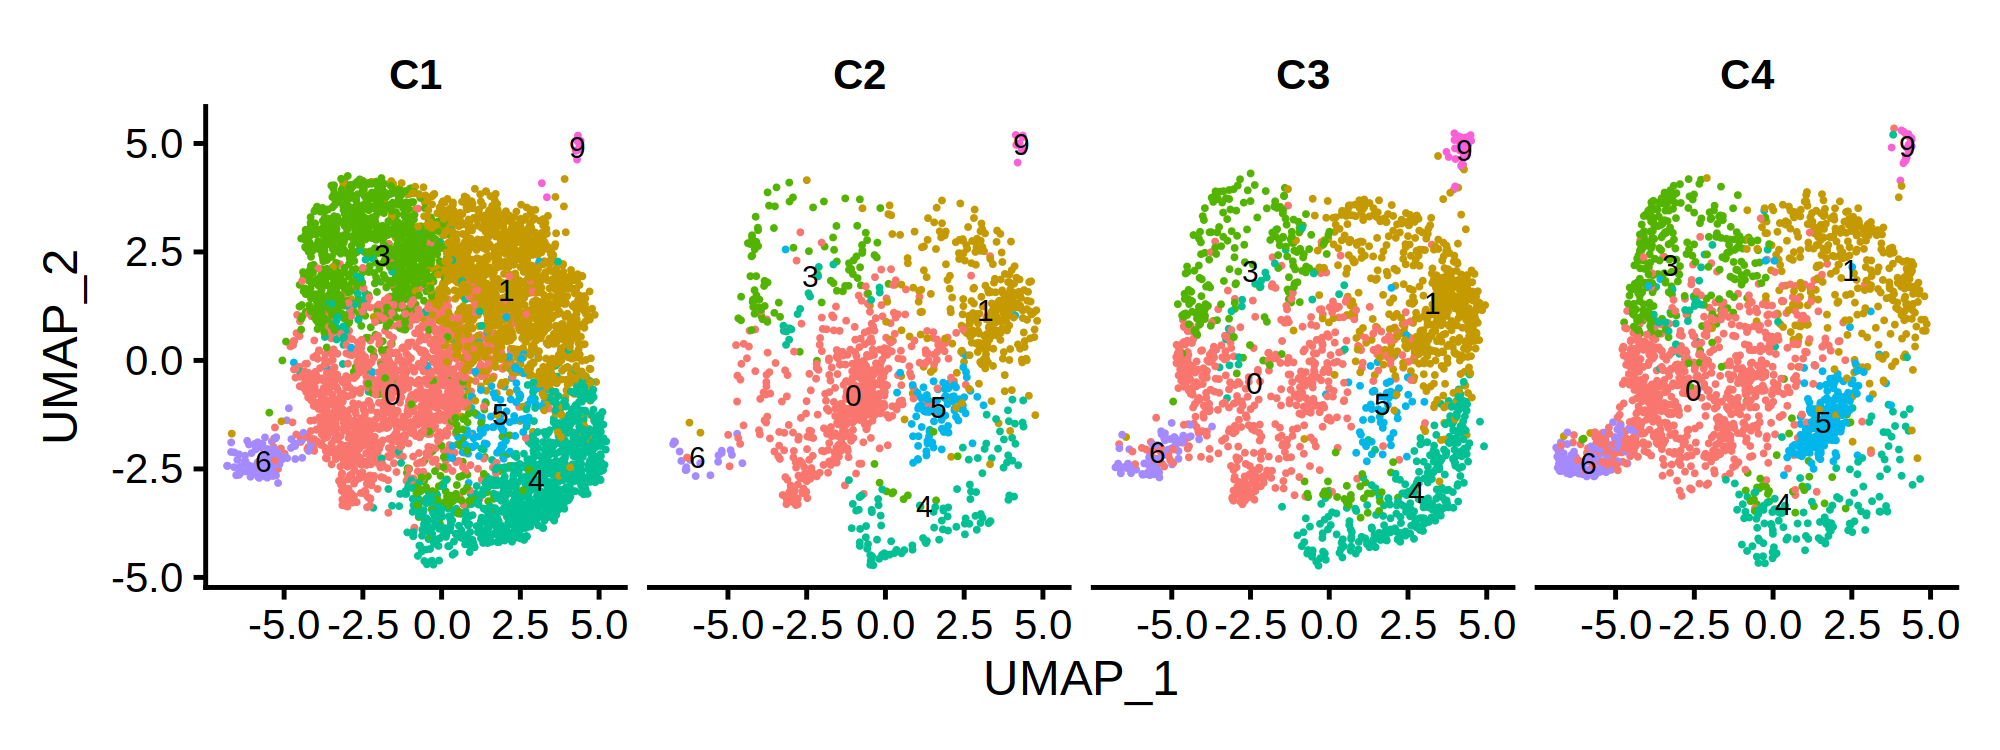

In [ ]:
options(repr.plot.width=8, repr.plot.height=3,repr.plot.res=250)
DimPlot(Epi, reduction = "umap", split.by = 'TME', label = TRUE, label.size = 3) + NoLegend()

In [ ]:
group = as.character(Epi$integrated_snn_res.0.4)
group[group == '0'] = '0:Stress'
group[group == '1'] = '1:Cell_death'
group[group == '3'] = '3:MHCII' 
group[group == '4'] = '4:PT'
group[group == '5'] = '5:Cell_death'
group[group == '6'] = '6:EMT'
group[group == '9'] = '7:Cell_cycle'
Epi$group <- group

l=0.03

png('figures/epi_umap_filtered_byEMT.png', width = 1500, height = 1500, res = 300)
DimPlot(Epi, reduction = "umap",group.by = 'group',label = F,split.by = 'TME', ncol = 2,cols = Colclus[c(1,2,4:7,10)]) & NoLegend() &
  theme(panel.grid = element_blank(),axis.title = element_blank(),plot.title = element_text(hjust = 0.5,face = 'bold'),
  axis.text = element_blank(),axis.ticks=element_blank(),axis.line = element_blank())
dev.off()

png 
  2

In [ ]:
Freq = table(Epi$sample,as.character(Epi$`integrated_snn_res.0.4`)) %>% as.data.frame.array
Freq <- t(Freq)/colSums(Freq)
Freq <- data.frame(Freq,check.names = FALSE)
Freq <- Freq[c('1','5'),] %>% data.frame(check.names = FALSE)
Freq <- Freq %>% rownames_to_column(var = "Cluster")
Freq <- Freq %>% tidyr::pivot_longer(cols = -Cluster, names_to = "Sample", values_to = "Proportion")
Freq$TME <- as.character(Epi$TME[match(Freq$Sample, Epi$sample)])
head(Freq)

Cluster,Sample,Proportion,TME
<chr>,<chr>,<dbl>,<chr>
1,CRS-T1,0.02656546,C4
1,CRS-T2,0.10170778,C1
1,CRS-T3,0.01176471,C4
1,LLF-T1,0.04440228,C4
1,LLF-T2,0.11309298,C2
1,LLF-T3,0.16736243,C3


In [ ]:
Freq$Cluster = paste0(Freq$Cluster,':Cell_death')

In [ ]:
reorder_within <- function(x, by, within, fun = median, sep = "___") {
  new_x <- paste(x, within, sep = sep)
  stats::reorder(new_x, by, FUN = fun)
}
scale_x_reordered <- function(..., sep = "___") {
  reg <- paste0(sep, ".+$")
  ggplot2::scale_x_discrete(labels = function(x) gsub(reg, "", x), ...)
}

In [ ]:
options(repr.plot.width=6, repr.plot.height=3,repr.plot.res=250)
png('figures/epi_boxplot_TME.png', width = 700, height = 700, res = 300)
ggplot(Freq, aes(
  x = reorder_within(TME, -Proportion, Cluster),  # 按Cluster分组排序
  y = Proportion,
  fill = Cluster
)) +
  geom_boxplot(outlier.shape = NA) +
  geom_jitter(
    aes(color = Sample),
    position = position_jitterdodge(jitter.width = 0.2),
    size = 1,
    color = 'Grey70'
  ) +
  facet_wrap(~Cluster, scales = "free") +  
  scale_x_reordered() +  
  theme_bw() +
  labs(x = "TME", y = "Proportion") +
  scale_fill_manual(values = c('#AEC7E8FF','#C5B0D5FF')) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    axis.title.x = element_blank(),
    legend.position = 'none',
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    strip.background = element_blank()
  ) +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.05)))
dev.off()

png 
  2

### cell_death 1 and 5

In [ ]:
DEGs <- FindMarkers(combined.sct, ident.1 = '1', ident.2 = '5', only.pos = FALSE, min.pct = 0.25, logfc.threshold = -Inf,return.thresh = 0.05,assay = 'RNA')
DEGs <- DEGs %>% filter(p_val_adj < 0.05)
DEGs <- DEGs %>% arrange(desc(avg_log2FC))
DEGs[1:5,]

In [ ]:
# write.csv(DEGs, file = 'results/DEGs_1_vs_5.csv')
DEGs <- read.csv(file = 'results/DEGs_1_vs_5.csv', row.names = 1)
head(DEGs)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MACC1,3.025403e-33,1.156904,0.618,0.372,1.008760e-28
NLGN1,2.058539e-51,1.141738,0.978,0.920,6.863786e-47
PTH2R,1.362789e-47,1.105048,0.896,0.681,4.543946e-43
ITGB8,2.648525e-32,1.055419,0.784,0.611,8.830977e-28
SAMD4A,4.241680e-25,1.018883,0.791,0.656,1.414303e-20
HHLA2,7.812437e-29,1.000453,0.490,0.260,2.604901e-24


In [ ]:
library(fgsea)
library(clusterProfiler)
pathways=read.gmt('/mnt/data/wangj/scripts/h.all.v2025.1.Hs.symbols.gmt')
# pathways = filter(pathways,grepl('GOBP',pathways$term))

genelist <- DEGs$avg_log2FC
names(genelist) <- rownames(DEGs)

set.seed(233)
fgsea <- GSEA(sort(genelist,decreasing=T), 
              exponent = 1, 
              minGSSize = 5,
              maxGSSize = 1000, 
              pvalueCutoff = 1, 
              pAdjustMethod = "BH", 
              TERM2GENE=pathways,
              seed = 233,
              by = "fgsea",
              eps=0)


preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.29% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


leading edge analysis...

done...



In [ ]:
df = fgsea@result
df = filter(df, pvalue < 0.05)
df = df[order(df$NES,decreasing=T),]
df$Description = gsub('GOBP_','',df$Description)
df$Description = gsub('HALLMARK_','',df$Description)
# df$Description = stringr::str_to_title(df$Description, locale = "en")
df$Description = gsub('_',' ',df$Description)
head(df)

,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
HALLMARK_ESTROGEN_RESPONSE_EARLY,HALLMARK_ESTROGEN_RESPONSE_EARLY,ESTROGEN RESPONSE EARLY,32,0.5599340,2.667782,6.371486e-07,2.867169e-05,0.0000234739,239,"tags=50%, list=14%, signal=44%",BCL2/MAST4/WWC1/RETREG1/FARP1/RBBP8/ABLIM1/SVIL/BHLHE40/UGCG/ELOVL5/KLF10/NRIP1/SLC22A5/KAZN/ELF1
HALLMARK_IL2_STAT5_SIGNALING,HALLMARK_IL2_STAT5_SIGNALING,IL2 STAT5 SIGNALING,31,0.3778031,1.790411,1.726244e-02,7.768098e-02,0.0635984664,235,"tags=39%, list=13%, signal=34%",ITGAV/BCL2/KLF6/TNFRSF21/BHLHE40/NFIL3/RORA/NRP1/PLSCR1/CDC42SE2/DENND5A/BMPR2
HALLMARK_TNFA_SIGNALING_VIA_NFKB,HALLMARK_TNFA_SIGNALING_VIA_NFKB,TNFA SIGNALING VIA NFKB,42,0.3418419,1.777840,8.648442e-03,4.324221e-02,0.0354029776,284,"tags=38%, list=16%, signal=33%",KLF6/BIRC3/BHLHE40/KLF10/NFIL3/NFE2L2/CFLAR/TNFAIP6/PDLIM5/NFKB1/B4GALT5/DENND5A/SMAD3/CCNL1/FOSL2/RCAN1
HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,EPITHELIAL MESENCHYMAL TRANSITION,28,-0.3873547,-1.889344,7.039377e-03,4.324221e-02,0.0354029776,342,"tags=54%, list=20%, signal=44%",ENO2/TGFB1/EMP3/CADM1/GADD45B/HTRA1/JUN/LOX/GADD45A/TIMP1/ID2/VIM/LGALS1/SERPINE1/TGFBI
HALLMARK_HYPOXIA,HALLMARK_HYPOXIA,HYPOXIA,52,-0.3297309,-1.941177,2.109350e-03,1.898415e-02,0.0155425815,301,"tags=38%, list=17%, signal=33%",FOS/PPP1R3C/CDKN1C/JUN/LOX/GLRX/STC1/SLC2A3/CITED2/MT1E/GYS1/CXCR4/MT2A/DUSP1/PGF/LDHC/SERPINE1/DDIT4/TGFBI/AMPD3
HALLMARK_P53_PATHWAY,HALLMARK_P53_PATHWAY,P53 PATHWAY,35,-0.3759097,-1.965365,3.680690e-03,2.760518e-02,0.0226007295,621,"tags=74%, list=36%, signal=49%",EI24/ZMAT3/EPS8L2/ACVR1B/HDAC3/PLK2/BAIAP2/CDKN2AIP/CSRNP2/PHLDA3/IER5/IER3/SAT1/TGFB1/RPS27L/FOS/JUN/TXNIP/GADD45A/NUPR1/RACK1/HEXIM1/RPL18/RPS12/RPL36/DDIT4


In [ ]:
# df_plot = rbind(df[order(df$NES,decreasing = T),] %>% head(10),df[order(df$NES,decreasing = T),] %>% tail(10))
df_plot = df

In [ ]:
df_plot$group = ifelse(df_plot$NES > 0, 'Positive', 'Negative')
df_plot$geneID = df_plot$core_enrichment
head(df_plot)

,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment,group,geneID
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
HALLMARK_ESTROGEN_RESPONSE_EARLY,HALLMARK_ESTROGEN_RESPONSE_EARLY,ESTROGEN RESPONSE EARLY,32,0.5599340,2.667782,6.371486e-07,2.867169e-05,0.0000234739,239,"tags=50%, list=14%, signal=44%",BCL2/MAST4/WWC1/RETREG1/FARP1/RBBP8/ABLIM1/SVIL/BHLHE40/UGCG/ELOVL5/KLF10/NRIP1/SLC22A5/KAZN/ELF1,Positive,BCL2/MAST4/WWC1/RETREG1/FARP1/RBBP8/ABLIM1/SVIL/BHLHE40/UGCG/ELOVL5/KLF10/NRIP1/SLC22A5/KAZN/ELF1
HALLMARK_IL2_STAT5_SIGNALING,HALLMARK_IL2_STAT5_SIGNALING,IL2 STAT5 SIGNALING,31,0.3778031,1.790411,1.726244e-02,7.768098e-02,0.0635984664,235,"tags=39%, list=13%, signal=34%",ITGAV/BCL2/KLF6/TNFRSF21/BHLHE40/NFIL3/RORA/NRP1/PLSCR1/CDC42SE2/DENND5A/BMPR2,Positive,ITGAV/BCL2/KLF6/TNFRSF21/BHLHE40/NFIL3/RORA/NRP1/PLSCR1/CDC42SE2/DENND5A/BMPR2
HALLMARK_TNFA_SIGNALING_VIA_NFKB,HALLMARK_TNFA_SIGNALING_VIA_NFKB,TNFA SIGNALING VIA NFKB,42,0.3418419,1.777840,8.648442e-03,4.324221e-02,0.0354029776,284,"tags=38%, list=16%, signal=33%",KLF6/BIRC3/BHLHE40/KLF10/NFIL3/NFE2L2/CFLAR/TNFAIP6/PDLIM5/NFKB1/B4GALT5/DENND5A/SMAD3/CCNL1/FOSL2/RCAN1,Positive,KLF6/BIRC3/BHLHE40/KLF10/NFIL3/NFE2L2/CFLAR/TNFAIP6/PDLIM5/NFKB1/B4GALT5/DENND5A/SMAD3/CCNL1/FOSL2/RCAN1
HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,EPITHELIAL MESENCHYMAL TRANSITION,28,-0.3873547,-1.889344,7.039377e-03,4.324221e-02,0.0354029776,342,"tags=54%, list=20%, signal=44%",ENO2/TGFB1/EMP3/CADM1/GADD45B/HTRA1/JUN/LOX/GADD45A/TIMP1/ID2/VIM/LGALS1/SERPINE1/TGFBI,Negative,ENO2/TGFB1/EMP3/CADM1/GADD45B/HTRA1/JUN/LOX/GADD45A/TIMP1/ID2/VIM/LGALS1/SERPINE1/TGFBI
HALLMARK_HYPOXIA,HALLMARK_HYPOXIA,HYPOXIA,52,-0.3297309,-1.941177,2.109350e-03,1.898415e-02,0.0155425815,301,"tags=38%, list=17%, signal=33%",FOS/PPP1R3C/CDKN1C/JUN/LOX/GLRX/STC1/SLC2A3/CITED2/MT1E/GYS1/CXCR4/MT2A/DUSP1/PGF/LDHC/SERPINE1/DDIT4/TGFBI/AMPD3,Negative,FOS/PPP1R3C/CDKN1C/JUN/LOX/GLRX/STC1/SLC2A3/CITED2/MT1E/GYS1/CXCR4/MT2A/DUSP1/PGF/LDHC/SERPINE1/DDIT4/TGFBI/AMPD3
HALLMARK_P53_PATHWAY,HALLMARK_P53_PATHWAY,P53 PATHWAY,35,-0.3759097,-1.965365,3.680690e-03,2.760518e-02,0.0226007295,621,"tags=74%, list=36%, signal=49%",EI24/ZMAT3/EPS8L2/ACVR1B/HDAC3/PLK2/BAIAP2/CDKN2AIP/CSRNP2/PHLDA3/IER5/IER3/SAT1/TGFB1/RPS27L/FOS/JUN/TXNIP/GADD45A/NUPR1/RACK1/HEXIM1/RPL18/RPS12/RPL36/DDIT4,Negative,EI24/ZMAT3/EPS8L2/ACVR1B/HDAC3/PLK2/BAIAP2/CDKN2AIP/CSRNP2/PHLDA3/IER5/IER3/SAT1/TGFB1/RPS27L/FOS/JUN/TXNIP/GADD45A/NUPR1/RACK1/HEXIM1/RPL18/RPS12/RPL36/DDIT4


In [ ]:
gdf_plot_merge = merge_genesets(df_plot,'group')

In [ ]:
options(repr.plot.width=7, repr.plot.height=5,repr.plot.res=200)
png('figures/epi_fgsea_barplot.png', width = 1500, height = 1700, res = 300)
ggplot(gdf_plot_merge, aes(x = NES, y = reorder(Description, NES), fill = NES)) +
  geom_bar(stat = "identity") +
  theme_bw() +
  geom_text(aes(label = Description,hjust = ifelse(NES>0,1,0),x = ifelse(NES>0,-0.1,0.1)),color = "black",size = 3.3) +
  scale_fill_gradient2(low = "#51C3CC", mid = "white", high = "#DF0000", midpoint = 0) +
  labs(x = "Normalized Enrichment Score (NES)", y = NULL) +
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank(),panel.grid = element_blank(),
        legend.position = 'right',strip.background = element_blank(),strip.text = element_blank()) +
  scale_x_continuous(expand = expansion(add = c(0, 0.05)))+
  xlim(-3,3)+
  ggtitle("DEGs: 1:Cell_death vs. 5:Cell_death")
dev.off()

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


png 
  2